# Comparison of the ways to compute k_on and k_off

For a DNA strand A and its complement B, we're interested in computing the kinetics rates of the hybridization (k_on) and the dehybridization (k_off).

This notebook aims to compare two ways for this computation.

In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math

from nupack import Model, Strand, Complex, Tube, SetSpec, tube_analysis


code_dir = os.path.expanduser("~/Documents/PLR1/pen-dna-simulator/")
sys.path.append(code_dir)

from strands import Signal, Drain, Template


def reverse_complement(seq):
    """
    Returns the reverse complement of a DNA sequence.
    """
    complement = str.maketrans("ATCGatcg", "TAGCtagc")
    return seq.translate(complement)[::-1]

import random
def random_sequence(length):
    bases = ['A', 'T', 'C', 'G']
    return ''.join(random.choice(bases) for _ in range(length))


In [3]:
def compute_koff_NN_1MNaCl(seq,temp):
    """Computes the dissociation rate k_off between a DNA strand and its complementary strand, with the nearest neighbor model described by Rejali et al.
    in the case of 1M NaCl. 
    The result is given in s-1 units."""
    kb=1.3e-23
    h=6.6e-34
    R=8.314
    temp+=273 # °C -> K

    dict_H={
    'AA':9.2,
    'TT':9.2,
    'AT':8.6,
    'TA':5.6,
    'CA':11.9,
    'TG':11.9,
    'GT':9.6,
    'AC':9.6,
    'CT':10.2,
    'AG':10.2,
    'GA':8.1,
    'TC':8.1,
    'CG':14.5,
    'GC':11.2,
    'GG':9.8,
    'CC':9.8,
    'init':-14.8,
    'term':-1
    }

    dict_S={
    'AA':26.5,
    'TT':26.5,
    'AT':24.2,
    'TA':15.8,
    'CA':33.5,
    'TG':33.5,
    'GT':25.9,
    'AC':25.9,
    'CT':28.9,
    'AG':28.9,
    'GA':21.7,
    'TC':21.7,
    'CG':40.7,
    'GC':29.2,
    'GG':26.6,
    'CC':26.6,
    'init':-66.8,
    'term':-2.3
    }

    dH=dict_H['init']
    dS=dict_S['init']
    for i in range (len(seq)-1):
        couple=seq[i:i+2]
        dH+=dict_H[couple]
        dS+=dict_S[couple]
    if seq[0]=='A' or seq[0]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    if seq[-1]=='A' or seq[-1]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    dH *= 4184  # kcal/mol → J/mol
    dS *= 4.184  # cal/mol·K → J/mol·K
    dG=dH - temp*dS
    koff=(kb * temp / h) * math.exp(-dG/(R*temp))
    return koff

def compute_koff_NN_2mMMgCl(seq,temp):
    """Computes the dissociation rate k_off between a DNA strand and its complementary strand, with the nearest neighbor model described by Rejali et al.,
    in the case of 2.2 mM MgCl2.
    The result is given in s-1 units."""
    kb=1.3e-23
    h=6.6e-34
    R=8.314
    temp+=273 # °C -> K

    dict_H={
    'AA':9.6,
    'TT':9.6,
    'AT':11.0,
    'TA':3.7,
    'CA':10.0,
    'TG':10.0,
    'GT':12.0,
    'AC':12.0,
    'CT':9.8,
    'AG':9.8,
    'GA':7.4,
    'TC':7.4,
    'CG':13.2,
    'GC':11.6,
    'GG':11.3,
    'CC':11.3,
    'init':-10.5,
    'term':-3.0
    }

    dict_S={
    'AA':28.0,
    'TT':28.0,
    'AT':32.8,
    'TA':10.0,
    'CA':27.6,
    'TG':27.6,
    'GT':34.0,
    'AC':34.0,
    'CT':27.2,
    'AG':27.2,
    'GA':20.1,
    'TC':20.1,
    'CG':36.0,
    'GC':31.3,
    'GG':31.2,
    'CC':31.2,
    'init':-54,
    'term':-8.7
    }

    dH=dict_H['init']
    dS=dict_S['init']
    for i in range (len(seq)-1):
        couple=seq[i:i+2]
        dH+=dict_H[couple]
        dS+=dict_S[couple]
    if seq[0]=='A' or seq[0]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    if seq[-1]=='A' or seq[-1]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    dH *= 4184  # kcal/mol → J/mol
    dS *= 4.184  # cal/mol·K → J/mol·K
    dG=dH - temp*dS
    koff=(kb * temp / h) * math.exp(-dG/(R*temp))
    return koff

def compute_kon_NN_1MNaCl(seq,temp):
    """Computes the association rate k_on between a DNA strand and its complementary strand, with the nearest neighbor model described by Rejali et al. 
    in the case of 1M NaCl.
    The result is given in M-1.s-1 units."""
    kb=1.3e-23
    h=6.6e-34
    R=8.314
    temp+=273 # °C -> K

    dict_H={
    'AA':0,
    'TT':0,
    'AT':0,
    'TA':0,
    'CA':0,
    'TG':0,
    'GT':0,
    'AC':0,
    'CT':0,
    'AG':0,
    'GA':0,
    'TC':0,
    'CG':0,
    'GC':0,
    'GG':0,
    'CC':0,
    'init':0,
    'term':0
    }

    dict_S={
    'AA':-0.08,
    'TT':-0.08,
    'AT':-0.16,
    'TA':-0.41,
    'CA':-0.35,
    'TG':-0.35,
    'GT':-0.02,
    'AC':-0.02,
    'CT':-0.29,
    'AG':-0.29,
    'GA':-0.22,
    'TC':-0.22,
    'CG':0.08,
    'GC':-0.02,
    'GG':0.47,
    'CC':0.47,
    'init':-25.1,
    'term':0.32
    }

    dH=dict_H['init']
    dS=dict_S['init']
    for i in range (len(seq)-1):
        couple=seq[i:i+2]
        dH+=dict_H[couple]
        dS+=dict_S[couple]
    if seq[0]=='A' or seq[0]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    if seq[-1]=='A' or seq[-1]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    dH *= 4184  # kcal/mol → J/mol
    dS *= 4.184  # cal/mol·K → J/mol·K
    dG=dH - temp*dS
    kon=(kb * temp / h) * math.exp(-dG/(R*temp))
    return kon

def compute_kon_NN_2mMMgCl(seq,temp):
    """Computes the association rate k_on between a DNA strand and its complementary strand, with the nearest neighbor model described by Rejali et al. 
    in the case of 2.2 mM MgCl2.
    The result is given in M-1.s-1 units."""
    kb=1.3e-23
    h=6.6e-34
    R=8.314
    temp+=273 # °C -> K

    dict_H={
    'AA':0,
    'TT':0,
    'AT':0,
    'TA':0,
    'CA':0,
    'TG':0,
    'GT':0,
    'AC':0,
    'CT':0,
    'AG':0,
    'GA':0,
    'TC':0,
    'CG':0,
    'GC':0,
    'GG':0,
    'CC':0,
    'init':0,
    'term':0
    }

    dict_S={
    'AA':-0.37,
    'TT':-0.37,
    'AT':-0.24,
    'TA':-0.58,
    'CA':-0.24,
    'TG':-0.24,
    'GT':-0.24,
    'AC':-0.24,
    'CT':-0.52,
    'AG':-0.52,
    'GA':-0.22,
    'TC':-0.22,
    'CG':0.11,
    'GC':0.02,
    'GG':0.49,
    'CC':0.49,
    'init':-27.5,
    'term':0.31
    }

    dH=dict_H['init']
    dS=dict_S['init']
    for i in range (len(seq)-1):
        couple=seq[i:i+2]
        dH+=dict_H[couple]
        dS+=dict_S[couple]
    if seq[0]=='A' or seq[0]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    if seq[-1]=='A' or seq[-1]=='T':
        dH+=dict_H['term']
        dS+=dict_S['term']
    dH *= 4184  # kcal/mol → J/mol
    dS *= 4.184  # cal/mol·K → J/mol·K
    dG=dH - temp*dS
    kon=(kb * temp / h) * math.exp(-dG/(R*temp))
    return kon

def compute_Kd(seqA, seqB, concA, concB, temp_celsius=37.0, sodium=0.05, magnesium=0.012):
    """
    Computes the dissociation constant K_D = [A][B]/[AB] at equilibrium.

    Parameters:
        seqA (str): DNA sequence A.
        seqB (str): DNA sequence B (not necessarily the perfect complement).
        concA (float): Initial concentration of strand A (M).
        concB (float): Initial concentration of strand B (M).
        temp_celsius (float): Temperature in Celsius.
        sodium (float): Sodium ion concentration in M.
        magnesium (float): Magnesium ion concentration in M.

    Returns:
        float: Estimated K_D in M.
    """
    # Set up and call NUPACK model
    model = Model(material='dna', celsius=temp_celsius, sodium=sodium, magnesium=magnesium)
    A = Strand(seqA, name='A')
    B = Strand(seqB, name='B')
    duplex = Complex([A, B], name='Duplex')
    tube = Tube(strands={A: concA, B: concB}, complexes=SetSpec(max_size=2), name='Tube')
    result = tube_analysis(tubes=[tube], model=model)
    
    # Extract equilibrium concentrations
    conc_duplex = result.tubes[tube].complex_concentrations.get(duplex, 0.0)
    freeA = concA - conc_duplex
    freeB = concB - conc_duplex

    # Compute K_D
    if conc_duplex > 0:
        KD = (freeA * freeB) / conc_duplex
    else:
        KD = float('inf')  # Essentially no binding
    return KD

def compute_kon_from_koff1(seq,temp, sodium, magnesium):
    """Computes the association rate k_on between a DNA strand and its complementary strand, thanks to k_off and K_d.
    In M-1, s-1 units"""
    K_d=compute_Kd(seq, reverse_complement(seq),1e-8,1e-8,temp_celsius=temp, sodium=sodium, magnesium=magnesium)
    k_off=compute_koff_NN_1MNaCl(seq,temp)
    k_on=k_off/K_d
    return k_on

def compute_kon_from_koff2(seq,temp, sodium, magnesium):
    """Computes the association rate k_on between a DNA strand and its complementary strand, thanks to k_off and K_d.
    In M-1, s-1 units"""
    K_d=compute_Kd(seq, reverse_complement(seq),1e-8,1e-8,temp_celsius=temp, sodium=sodium, magnesium=magnesium)
    k_off=compute_koff_NN_2mMMgCl(seq,temp)
    k_on=k_off/K_d
    return k_on

def compute_koff_from_kon1(seq,temp, sodium, magnesium):
    """Computes the dissociation rate k_off between a DNA strand and its complementary strand, thanks to k_on and K_d.
    In s-1 units"""
    K_d=compute_Kd(seq, reverse_complement(seq),1e-8,1e-8,temp_celsius=temp, sodium=sodium, magnesium=magnesium)
    k_on=compute_kon_NN_1MNaCl(seq,temp)
    k_off=k_on*K_d
    return k_off

def compute_koff_from_kon2(seq,temp, sodium, magnesium):
    """Computes the dissociation rate k_off between a DNA strand and its complementary strand, thanks to k_on and K_d.
    In s-1 units"""
    K_d=compute_Kd(seq, reverse_complement(seq),1e-8,1e-8,temp_celsius=temp, sodium=sodium, magnesium=magnesium)
    k_on=compute_kon_NN_2mMMgCl(seq,temp)
    k_off=k_on*K_d
    return k_off


def compute_all_in_once(seq,temp, sodium, magnesium):
    K_d=compute_Kd(seq, reverse_complement(seq),1e-8,1e-8,temp_celsius=temp, sodium=sodium, magnesium=magnesium)
    k_on1=compute_kon_NN_1MNaCl(seq,temp)
    k_on2=compute_kon_NN_2mMMgCl(seq,temp)
    k_off1=compute_koff_NN_1MNaCl(seq,temp)
    k_off2=compute_koff_NN_2mMMgCl(seq,temp)
    k_on_from_koff1=k_off1/K_d
    k_on_from_koff2=k_off2/K_d
    k_off_from_kon1=k_on1*K_d
    k_off_from_kon2=k_on2*K_d
    return [(k_on1, k_off_from_kon1), (k_on2, k_off_from_kon2), (k_on_from_koff1, k_off1), (k_on_from_koff2, k_off2)]


## Effect of the temperature

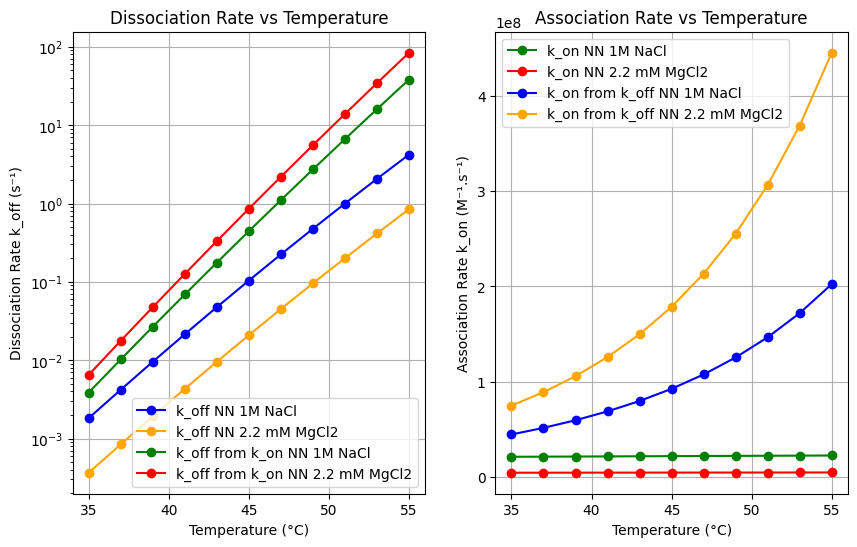

In [12]:
seq = "TAATCGGCAGGT"
temperatures = np.linspace(35, 55, 11)  # 35°C à 55°C par pas de 2°C
sodium = 0.05
magnesium = 0.012

kon1_list = []
kon2_list = []
kon3_list = []
kon4_list = []
koff1_list = []
koff2_list = []
koff3_list = []
koff4_list = []
for temp in temperatures:
    results = compute_all_in_once(seq, temp, sodium, magnesium)
    kon1_list.append(results[0][0])
    kon2_list.append(results[1][0])
    kon3_list.append(results[2][0])
    kon4_list.append(results[3][0])
    koff1_list.append(results[0][1])
    koff2_list.append(results[1][1])
    koff3_list.append(results[2][1])
    koff4_list.append(results[3][1])

plt.figure(figsize=(10, 6))

# k_off
plt.subplot(1, 2, 1)
plt.plot(temperatures, koff1_list, label='k_off NN 1M NaCl', marker='o', color='blue')
plt.plot(temperatures, koff2_list, label='k_off NN 2.2 mM MgCl2', marker='o', color='orange')
plt.plot(temperatures, koff3_list, label='k_off from k_on NN 1M NaCl', marker='o', color='green')
plt.plot(temperatures, koff4_list, label='k_off from k_on NN 2.2 mM MgCl2', marker='o', color='red')

plt.yscale('log')
plt.xlabel('Temperature (°C)')
plt.ylabel('Dissociation Rate k_off (s⁻¹)')
plt.title('Dissociation Rate vs Temperature')
plt.legend()
plt.grid()

# k_on
plt.subplot(1, 2, 2)
plt.plot(temperatures, kon1_list, label='k_on NN 1M NaCl', marker='o', color='green')
plt.plot(temperatures, kon2_list, label='k_on NN 2.2 mM MgCl2', marker='o', color='red')
plt.plot(temperatures, kon3_list, label='k_on from k_off NN 1M NaCl', marker='o', color='blue')
plt.plot(temperatures, kon4_list, label='k_on from k_off NN 2.2 mM MgCl2', marker='o', color='orange')

# plt.yscale('log')
plt.xlabel('Temperature (°C)')
plt.ylabel('Association Rate k_on (M⁻¹.s⁻¹)')
plt.title('Association Rate vs Temperature')
plt.legend()
plt.grid()

plt.savefig("rates_comparison.pdf")

The modelization errors are paid on the computation of k_on in the case we compute k_off with a NN model.

## Effect of the length

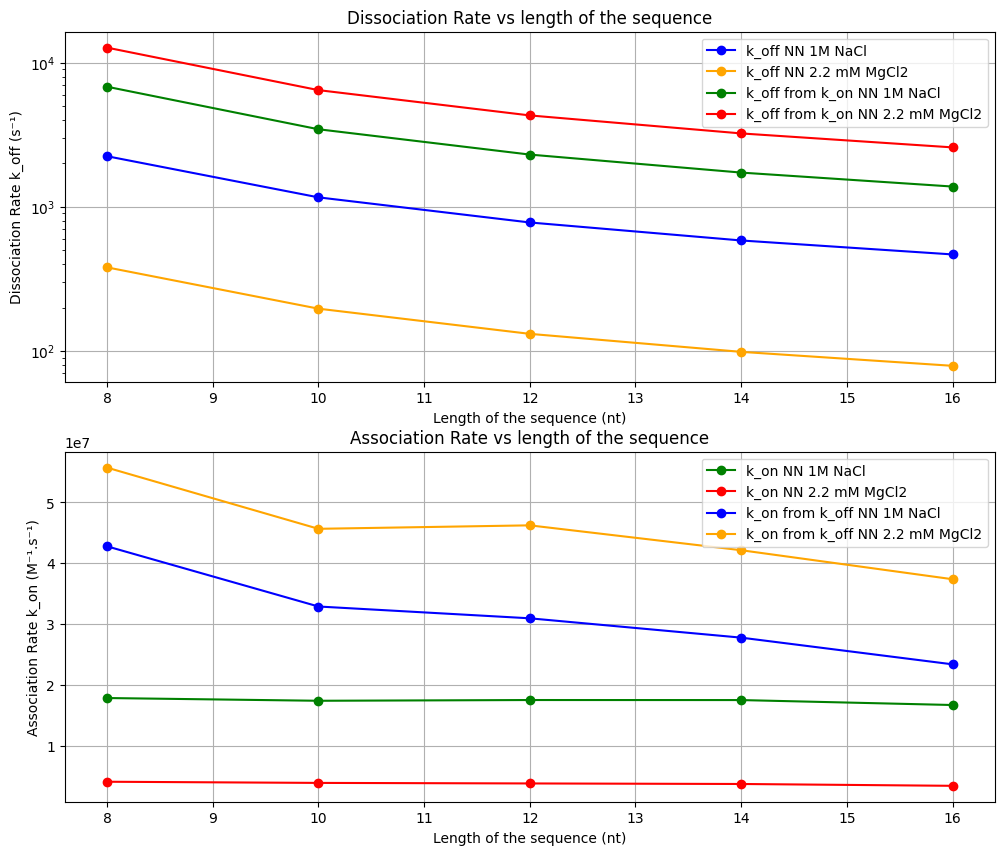

In [16]:
n_strands = 50
seq_length= np.linspace(8,16,5)

sodium = 0.05
magnesium = 0.012
temperature=45


kon1_list = []
kon2_list = []
kon3_list = []
kon4_list = []
koff1_list = []
koff2_list = []
koff3_list = []
koff4_list = []

kon1_means= []
kon2_means= []
kon3_means= []
kon4_means= []
koff1_means= []
koff2_means= []
koff3_means= []
koff4_means= []

for length in seq_length:
    for _ in range(n_strands):
        seq = random_sequence(int(length))
        results = compute_all_in_once(seq, temperature, sodium, magnesium)
        kon1_list.append(results[0][0])
        kon2_list.append(results[1][0])
        kon3_list.append(results[2][0])
        kon4_list.append(results[3][0])
        koff1_list.append(results[0][1])
        koff2_list.append(results[1][1])
        koff3_list.append(results[2][1])
        koff4_list.append(results[3][1])
    kon1_means.append(np.mean(kon1_list))
    kon2_means.append(np.mean(kon2_list))
    kon3_means.append(np.mean(kon3_list))
    kon4_means.append(np.mean(kon4_list))
    koff1_means.append(np.mean(koff1_list))
    koff2_means.append(np.mean(koff2_list))
    koff3_means.append(np.mean(koff3_list))
    koff4_means.append(np.mean(koff4_list))

plt.figure(figsize=(12, 10))

# k_off
plt.subplot(2, 1, 1)
plt.plot(seq_length, koff1_means, label='k_off NN 1M NaCl', marker='o', color='blue')
plt.plot(seq_length, koff2_means, label='k_off NN 2.2 mM MgCl2', marker='o', color='orange')
plt.plot(seq_length, koff3_means, label='k_off from k_on NN 1M NaCl', marker='o', color='green')
plt.plot(seq_length, koff4_means, label='k_off from k_on NN 2.2 mM MgCl2', marker='o', color='red')

plt.yscale('log')
plt.xlabel('Length of the sequence (nt)')
plt.ylabel('Dissociation Rate k_off (s⁻¹)')
plt.title('Dissociation Rate vs length of the sequence')
plt.legend()
plt.grid()

# k_on
plt.subplot(2, 1, 2)
plt.plot(seq_length, kon1_means, label='k_on NN 1M NaCl', marker='o', color='green')
plt.plot(seq_length, kon2_means, label='k_on NN 2.2 mM MgCl2', marker='o', color='red')
plt.plot(seq_length, kon3_means, label='k_on from k_off NN 1M NaCl', marker='o', color='blue')
plt.plot(seq_length, kon4_means, label='k_on from k_off NN 2.2 mM MgCl2', marker='o', color='orange')

# plt.yscale('log')
plt.xlabel('Length of the sequence (nt)')
plt.ylabel('Association Rate k_on (M⁻¹.s⁻¹)')
plt.title('Association Rate vs length of the sequence')
plt.legend()
plt.grid()


## Effects of the salts

TODO

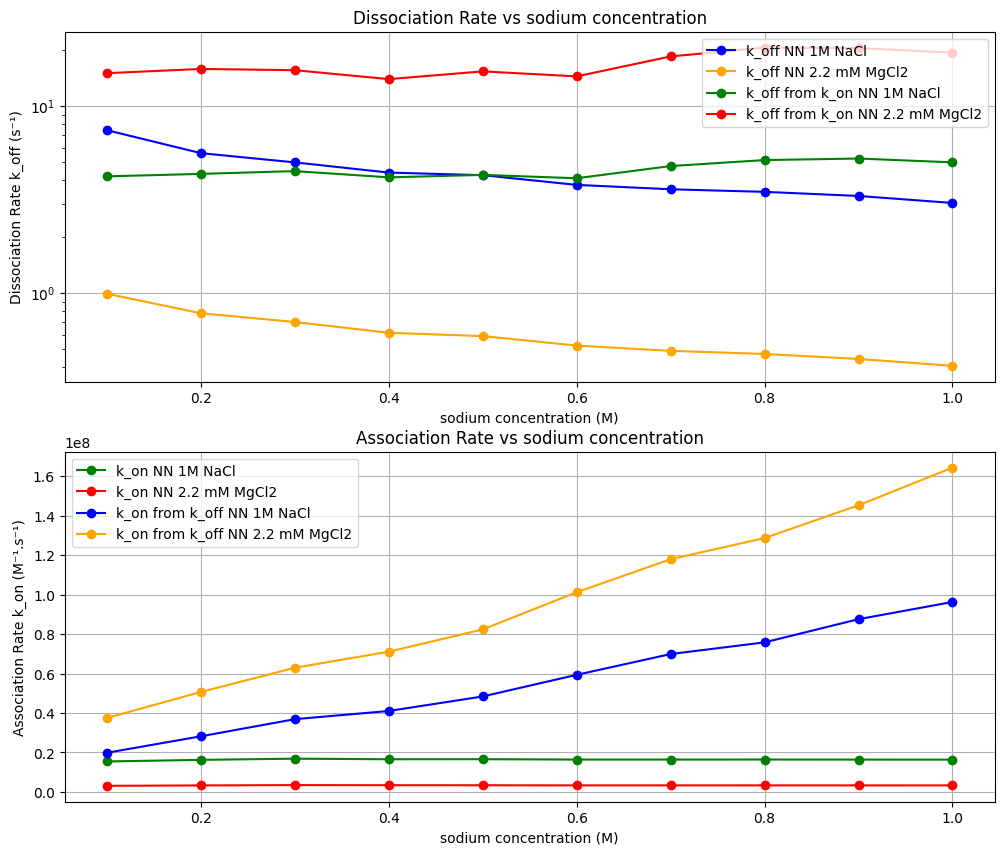

In [22]:
n_strands = 200
seq_length= 12

sodiums = np.linspace(0.1, 1, 10)
magnesium = 0.012
temperature=45


kon1_list = []
kon2_list = []
kon3_list = []
kon4_list = []
koff1_list = []
koff2_list = []
koff3_list = []
koff4_list = []

kon1_means= []
kon2_means= []
kon3_means= []
kon4_means= []
koff1_means= []
koff2_means= []
koff3_means= []
koff4_means= []

for sodium in sodiums:
    for _ in range(n_strands):
        seq = random_sequence(int(seq_length))
        results = compute_all_in_once(seq, temperature, sodium, magnesium)
        kon1_list.append(results[0][0])
        kon2_list.append(results[1][0])
        kon3_list.append(results[2][0])
        kon4_list.append(results[3][0])
        koff1_list.append(results[0][1])
        koff2_list.append(results[1][1])
        koff3_list.append(results[2][1])
        koff4_list.append(results[3][1])
    kon1_means.append(np.mean(kon1_list))
    kon2_means.append(np.mean(kon2_list))
    kon3_means.append(np.mean(kon3_list))
    kon4_means.append(np.mean(kon4_list))
    koff1_means.append(np.mean(koff1_list))
    koff2_means.append(np.mean(koff2_list))
    koff3_means.append(np.mean(koff3_list))
    koff4_means.append(np.mean(koff4_list))

plt.figure(figsize=(12, 10))

# k_off
plt.subplot(2, 1, 1)
plt.plot(sodiums, koff1_means, label='k_off NN 1M NaCl', marker='o', color='blue')
plt.plot(sodiums, koff2_means, label='k_off NN 2.2 mM MgCl2', marker='o', color='orange')
plt.plot(sodiums, koff3_means, label='k_off from k_on NN 1M NaCl', marker='o', color='green')
plt.plot(sodiums, koff4_means, label='k_off from k_on NN 2.2 mM MgCl2', marker='o', color='red')

plt.yscale('log')
plt.xlabel('sodium concentration (M)')
plt.ylabel('Dissociation Rate k_off (s⁻¹)')
plt.title('Dissociation Rate vs sodium concentration')
plt.legend()
plt.grid()

# k_on
plt.subplot(2, 1, 2)
plt.plot(sodiums, kon1_means, label='k_on NN 1M NaCl', marker='o', color='green')
plt.plot(sodiums, kon2_means, label='k_on NN 2.2 mM MgCl2', marker='o', color='red')
plt.plot(sodiums, kon3_means, label='k_on from k_off NN 1M NaCl', marker='o', color='blue')
plt.plot(sodiums, kon4_means, label='k_on from k_off NN 2.2 mM MgCl2', marker='o', color='orange')

# plt.yscale('log')
plt.xlabel('sodium concentration (M)')
plt.ylabel('Association Rate k_on (M⁻¹.s⁻¹)')
plt.title('Association Rate vs sodium concentration')
plt.legend()
plt.grid()


## Comparaison of k-on Mg and k_on Na

Correlation coefficient between k_on predictions: 0.95
Line of best fit: y = 0.26x + -1000137.14


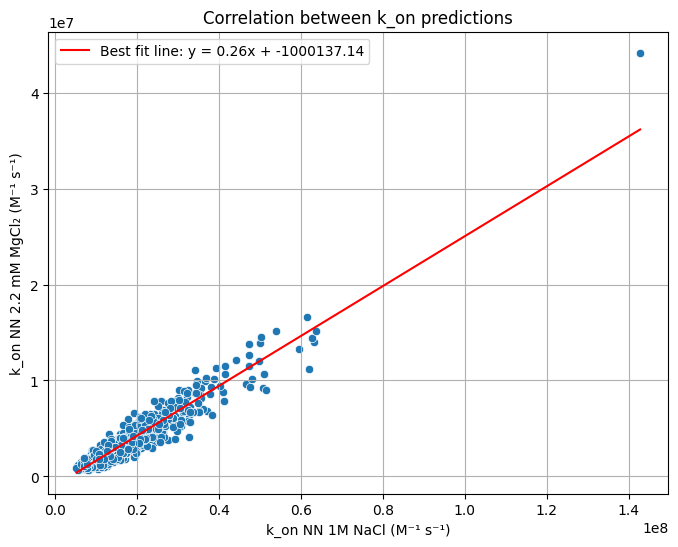

In [31]:
n_strands = 1000
seq_length= 12
magnesium = 0.012
temperature=45


kon1_list = []
kon2_list = []

for _ in range(n_strands):
    seq = random_sequence(int(seq_length))
    kon1_list.append(compute_kon_NN_1MNaCl(seq, temperature))
    kon2_list.append(compute_kon_NN_2mMMgCl(seq, temperature))

# Compute the correlation coefficient
correlation_coefficient = np.corrcoef(kon1_list, kon2_list)[0, 1]
print(f"Correlation coefficient between k_on predictions: {correlation_coefficient:.2f}")

# Compute the line of best fit
slope, intercept = np.polyfit(kon1_list, kon2_list, 1)
print(f"Line of best fit: y = {slope:.2f}x + {intercept:.2f}")

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.scatterplot(x=kon1_list, y=kon2_list)
# Print the straight line
x = np.array([min(kon1_list), max(kon1_list)])
y = slope * x + intercept
plt.plot(x, y, color='red', label=f'Best fit line: y = {slope:.2f}x + {intercept:.2f}')
plt.legend()
plt.xlabel('k_on NN 1M NaCl (M⁻¹ s⁻¹)')
plt.ylabel('k_on NN 2.2 mM MgCl₂ (M⁻¹ s⁻¹)')
plt.title('Correlation between k_on predictions')

plt.grid()
plt.show()

Correlation coefficient between k_on predictions: 1.00
Line of best fit: y = 1.19e-01x + 1.31e-01


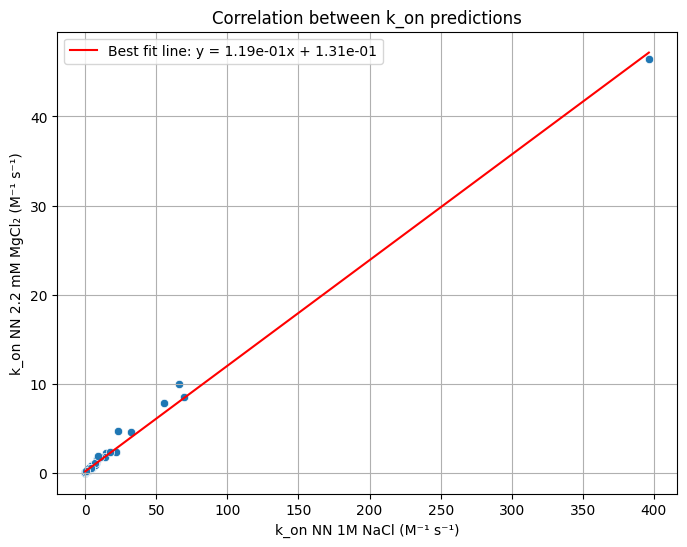

In [29]:
n_strands = 100
seq_length= 12
sodium=0.05
magnesium = 0.012
temperature=45


kon1_list = []
kon2_list = []

for _ in range(n_strands):
    seq = random_sequence(int(seq_length))
    kon1_list.append(compute_koff_from_kon1(seq, temperature, sodium=0.05, magnesium=0.012))
    kon2_list.append(compute_koff_from_kon2(seq, temperature, sodium=0.05, magnesium=0.012))

# Compute the correlation coefficient
correlation_coefficient = np.corrcoef(kon1_list, kon2_list)[0, 1]
print(f"Correlation coefficient between k_on predictions: {correlation_coefficient:.2f}")

# Compute the line of best fit
slope, intercept = np.polyfit(kon1_list, kon2_list, 1)
print(f"Line of best fit: y = {slope:.2e}x + {intercept:.2e}")

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.scatterplot(x=kon1_list, y=kon2_list)
# Print the straight line
x = np.array([min(kon1_list), max(kon1_list)])
y = slope * x + intercept
plt.plot(x, y, color='red', label=f'Best fit line: y = {slope:.2e}x + {intercept:.2e}')
plt.legend()
plt.xlabel('k_on NN 1M NaCl (M⁻¹ s⁻¹)')
plt.ylabel('k_on NN 2.2 mM MgCl₂ (M⁻¹ s⁻¹)')
plt.title('Correlation between k_on predictions')
plt.grid()
plt.show()

Correlation coefficient between k_on predictions: 0.36
Line of best fit: y = 1.04x + 2219899.28


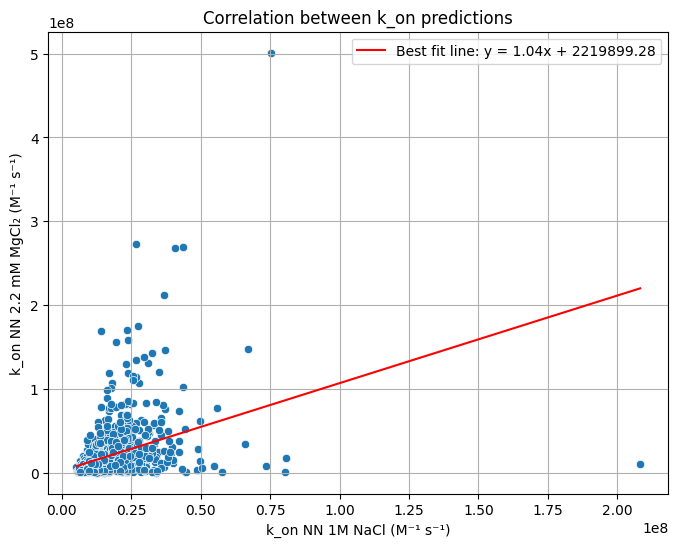

In [33]:
n_strands = 1000
seq_length= 12
magnesium = 0.012
temperature=45


kon1_list = []
kon2_list = []

for _ in range(n_strands):
    seq = random_sequence(int(seq_length))
    kon1_list.append(compute_kon_NN_1MNaCl(seq, temperature))
    kon2_list.append(compute_kon_from_koff1(seq, temperature, sodium, magnesium))

# Compute the correlation coefficient
correlation_coefficient = np.corrcoef(kon1_list, kon2_list)[0, 1]
print(f"Correlation coefficient between k_on predictions: {correlation_coefficient:.2f}")

# Compute the line of best fit
slope, intercept = np.polyfit(kon1_list, kon2_list, 1)
print(f"Line of best fit: y = {slope:.2f}x + {intercept:.2f}")

# Plot the correlation matrix
plt.figure(figsize=(8, 6))
sns.scatterplot(x=kon1_list, y=kon2_list)
# Print the straight line
x = np.array([min(kon1_list), max(kon1_list)])
y = slope * x + intercept
plt.plot(x, y, color='red', label=f'Best fit line: y = {slope:.2f}x + {intercept:.2f}')
plt.legend()
plt.xlabel('k_on NN 1M NaCl (M⁻¹ s⁻¹)')
plt.ylabel('k_on NN 2.2 mM MgCl₂ (M⁻¹ s⁻¹)')
plt.title('Correlation between k_on predictions')

plt.grid()
plt.show()